# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Sietske Huijbers
* Username: sehuijbers
* Student number: s6479979
* Group (AS1, etc.): AS4

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

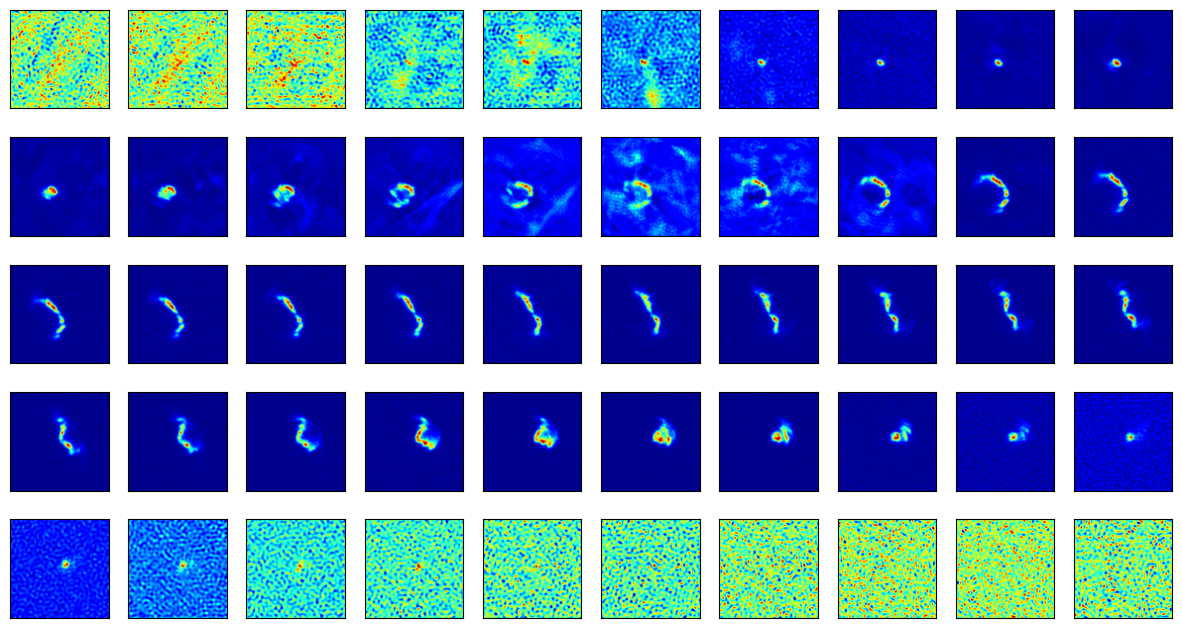

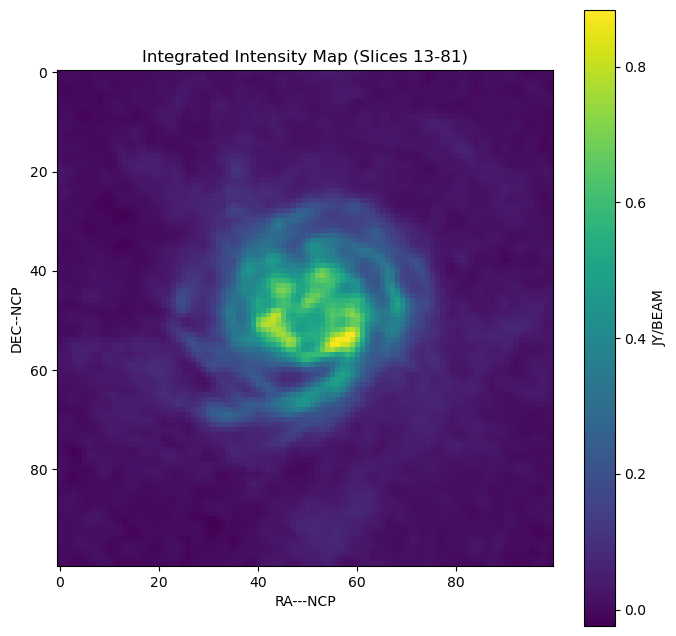

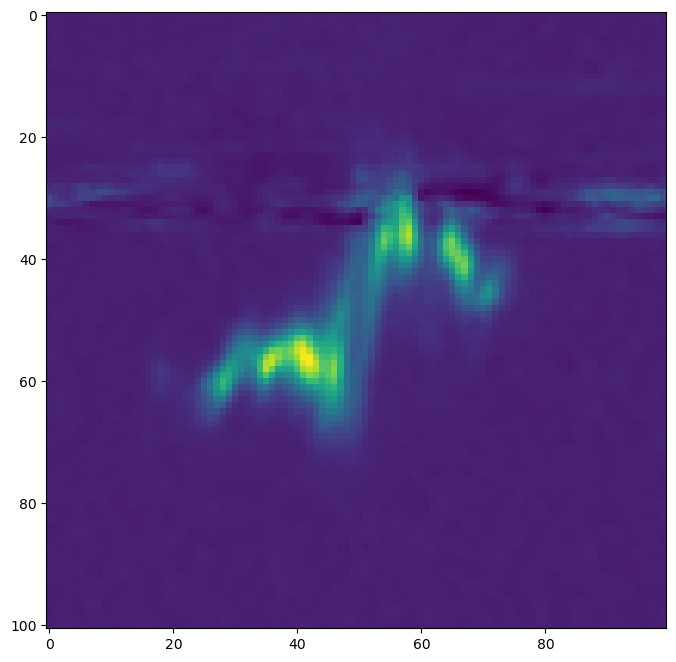

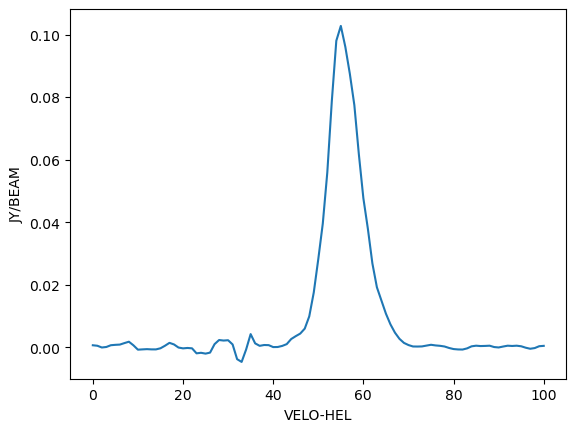

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits



hdulist = fits.open("./Downloads/ngc6946.fits") 
data = hdulist[0].data 
header = hdulist[0].header

ctype1 = header.get('CTYPE1', 'Right Ascension')
ctype2 = header.get('CTYPE2', 'Declination')
ctype3 = header.get('CTYPE3', 'Velocity')
bunit = header.get('BUNIT', 'Intensity')

indices = range(1, 101, 2)
fig, axes = plt.subplots(5,10,figsize=(15,8),sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(data[indices[i]], cmap='jet')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

plt.figure(figsize=(8, 8))
stack_range = range(13, 81, 2)

slices = [data[z] for z in stack_range]

staple = np.sum(slices, axis=0)

plt.imshow(staple)
plt.title("Integrated Intensity Map (Slices 13-81)")
plt.xlabel(ctype1)
plt.ylabel(ctype2)
plt.colorbar(label=bunit)
plt.show()

plt.figure(figsize=(8, 8))

pv = data[:,:,50]
plt.imshow(pv, aspect='auto')
plt.show()

spectra = data[:,40,50]
fig, ax = plt.subplots()
ax.plot(spectra)
ax.set_xlabel(header['CTYPE3'])
ax.set_ylabel(header['BUNIT'])
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

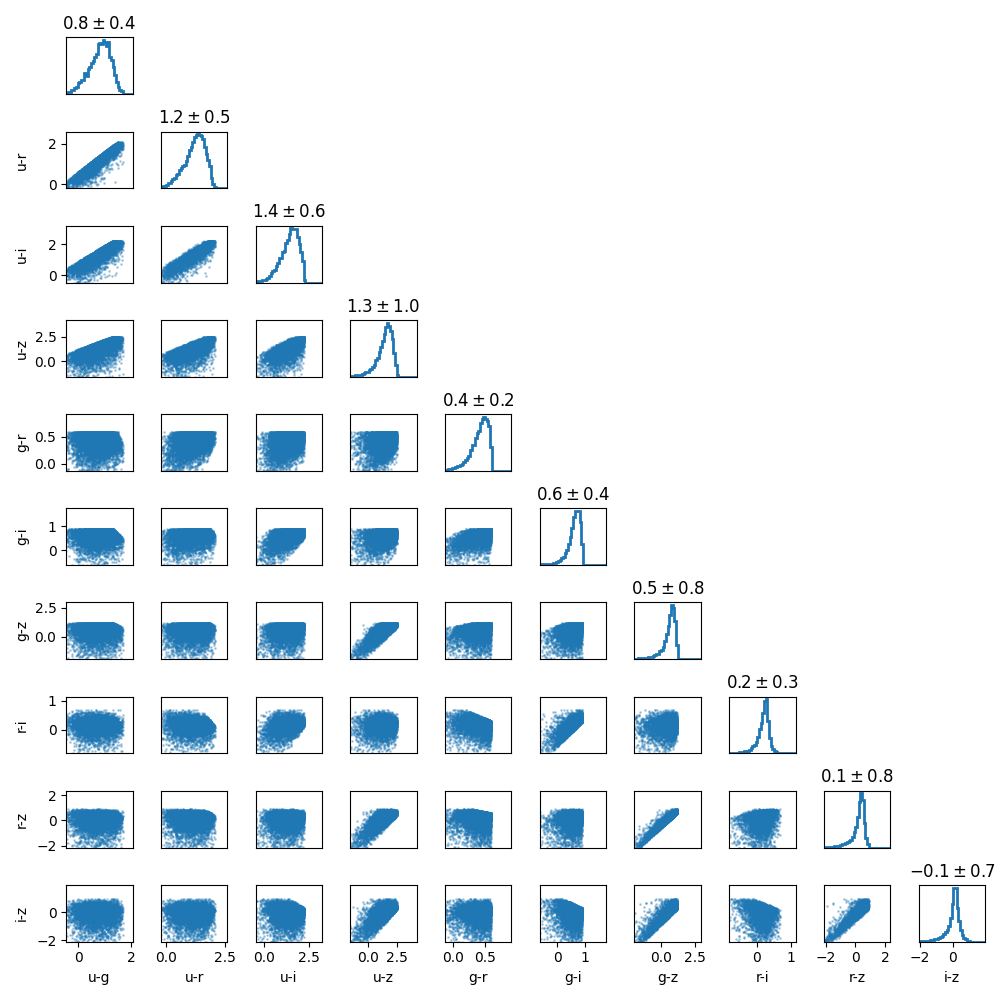
   
**Plot and answer**:

                 ObjID          u          g          r          i          z
0  1237667429572346493  22.133240  22.190250  21.788059  21.355808  21.630119
1  1237665225699688707  21.623161  21.394985  20.979010  20.807341  21.209600
2  1237661849859391812  21.970703  21.247322  20.650488  20.399561  20.187206
3  1237655464310014355  21.850883  21.075569  20.600910  20.281101  20.171160
4  1237668332564316684  22.198875  21.121441  20.892130  20.848957  20.391762
5  1237661066014883916  22.019781  22.288691  21.737526  21.400118  21.716976
6  1237657772324159767  19.667578  18.601091  18.133766  17.896601  17.683422
7  1237650795142447568  21.675821  21.246296  20.862551  20.627028  20.648396
8  1237660634388627953  22.245190  21.974373  21.485096  21.381182  21.068920
9  1237667782815187920  22.373613  21.599819  21.180758  20.842199  21.134071
u-g    0.804608
u-r    1.202665
u-i    1.369931
u-z    1.311232
g-r    0.398056
g-i    0.565322
g-z    0.506624
r-i    0.167266
r-z    0.10856

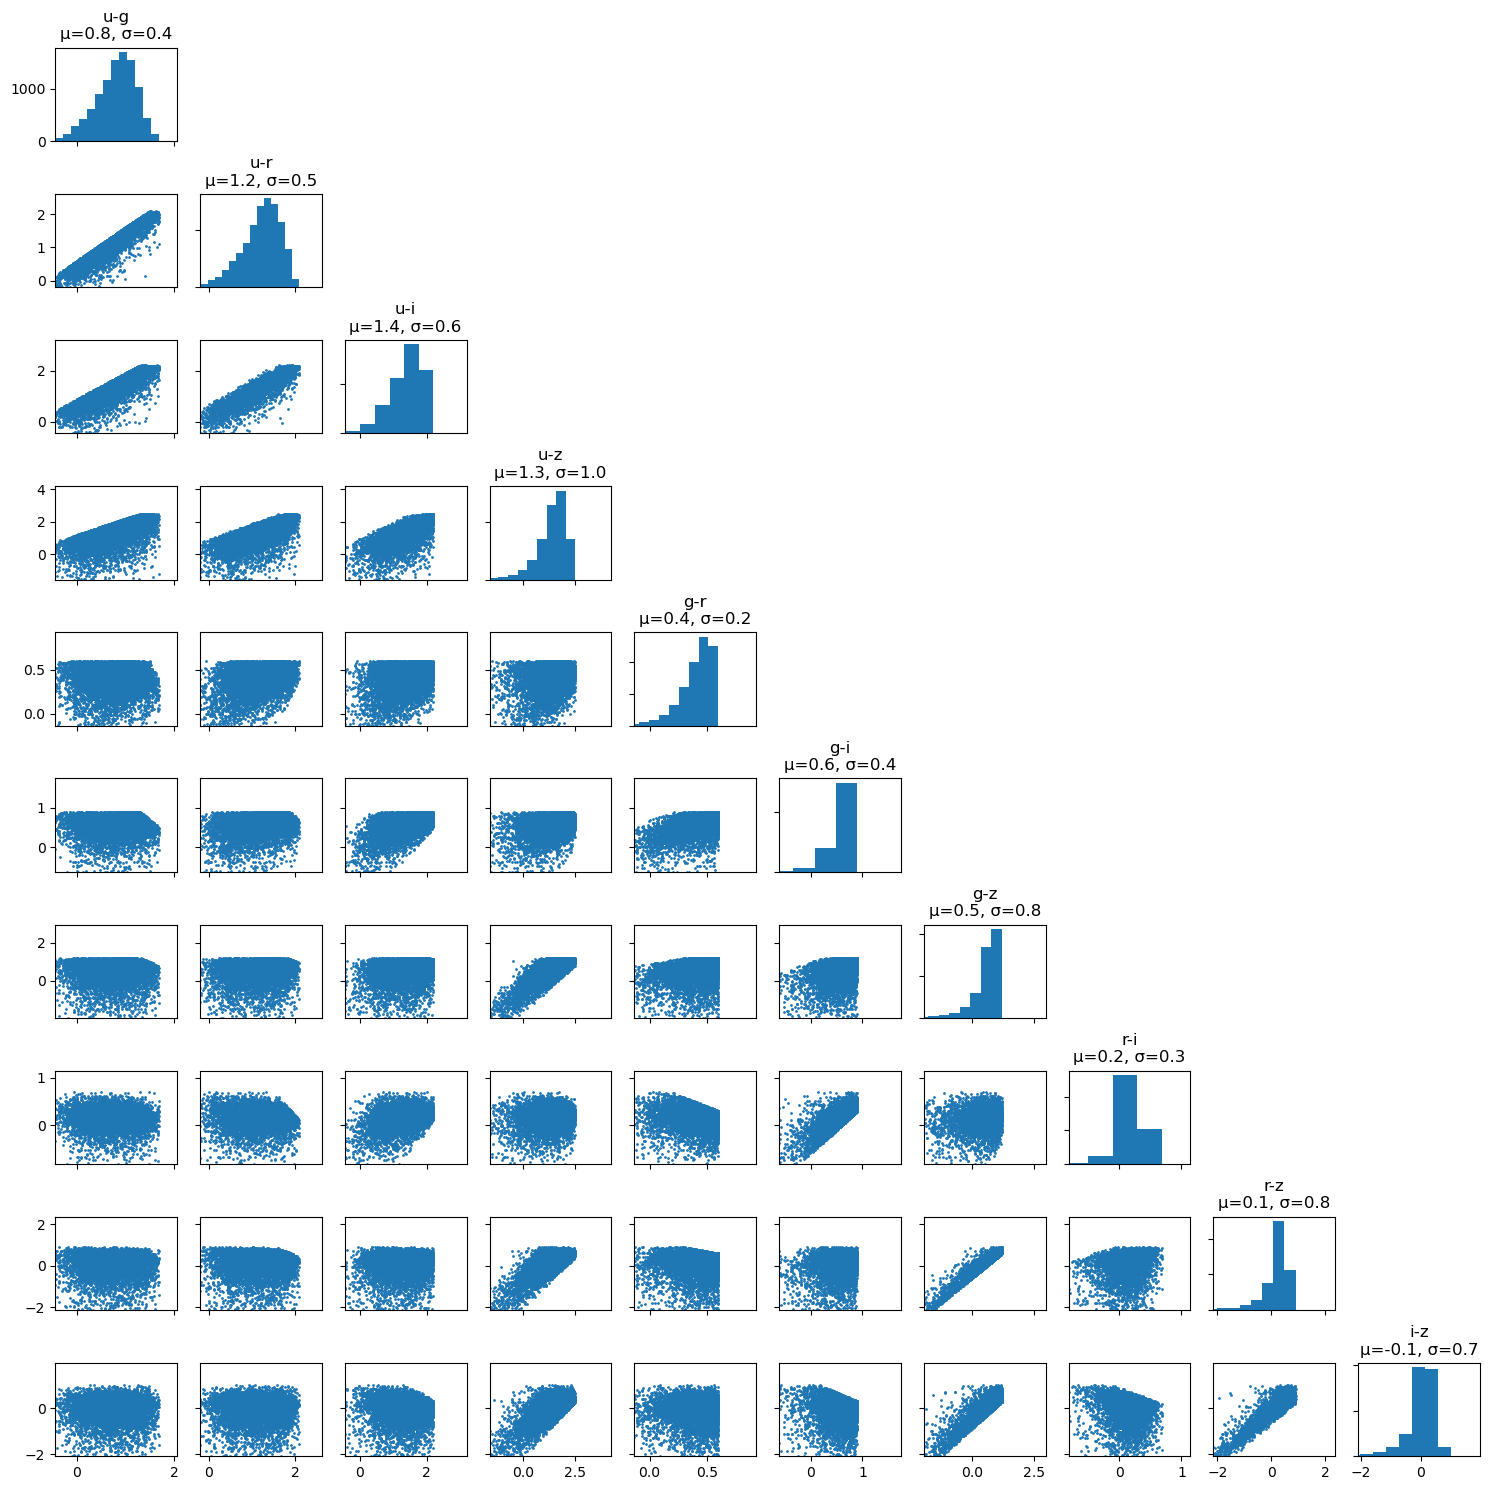

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pandas as pd

hdulist = fits.open("./Downloads/SDSS_DR17_galaxies.fits") 
header = hdulist[0].header
data = hdulist[1].data 
gal = pd.DataFrame(data)

pos = gal[(gal >= 0).all(axis=1)]
print(pos[:10])

colours = {
    "u-g": pos['u'] - pos['g'],
    "u-r": pos['u'] - pos['r'],
    "u-i": pos['u'] - pos['i'],
    "u-z": pos['u'] - pos['z'],
    "g-r": pos['g'] - pos['r'],
    "g-i": pos['g'] - pos['i'],
    "g-z": pos['g'] - pos['z'],
    "r-i": pos['r'] - pos['i'],
    "r-z": pos['r'] - pos['z'],
    "i-z": pos['i'] - pos['z'],
}frame = fig.add_subplot(1,3,1)
frame.imshow(dat, interpolation='none', origin="lower", cmap='gray')
frame = fig.add_subplot(1,3,2)
frame.imshow(dat, interpolation='none', origin="lower", cmap='gray', vmin=5000, vmax=10000)

col_df = pd.DataFrame(colours)
means = col_df.mean()
stds = col_df.std()

print(means)
print(stds)

import matplotlib.pyplot as plt

cols = col_df.columns
n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(15, 15))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
        if i < j: #to make it an traingle
            ax.axis('off')
            continue
        
        elif i == j:
            # to make Histogram
            data = col_df[cols[i]]
            mean = means[cols[i]]
            std = stds[cols[i]]
            
            ax.hist(data, bins=30)
            ax.set_xlim(mean - 3*std, mean + 3*std)
            ax.set_title(f"{cols[i]}\nμ={mean}, σ={std}")
        
        else:
            x = col_df[cols[j]] # Scatter plot
            y = col_df[cols[i]]
            
            ax.scatter(x, y, s=1)
            ax.set_xlim(means[cols[j]] - 3*stds[cols[j]],
                        means[cols[j]] + 3*stds[cols[j]])
            
            ax.set_ylim(means[cols[i]] - 3*stds[cols[i]],
                        means[cols[i]] + 3*stds[cols[i]])
        
        # Clean up labels
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

In [13]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

![M77.png](attachment:ad565bb5-5f92-4c74-a96a-5cc7a9a786f2.png)

In [47]:
pip install astroquery

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 28.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [astroquery]3 [astroquery]
Note: you may need to restart the kernel to use updated packages.


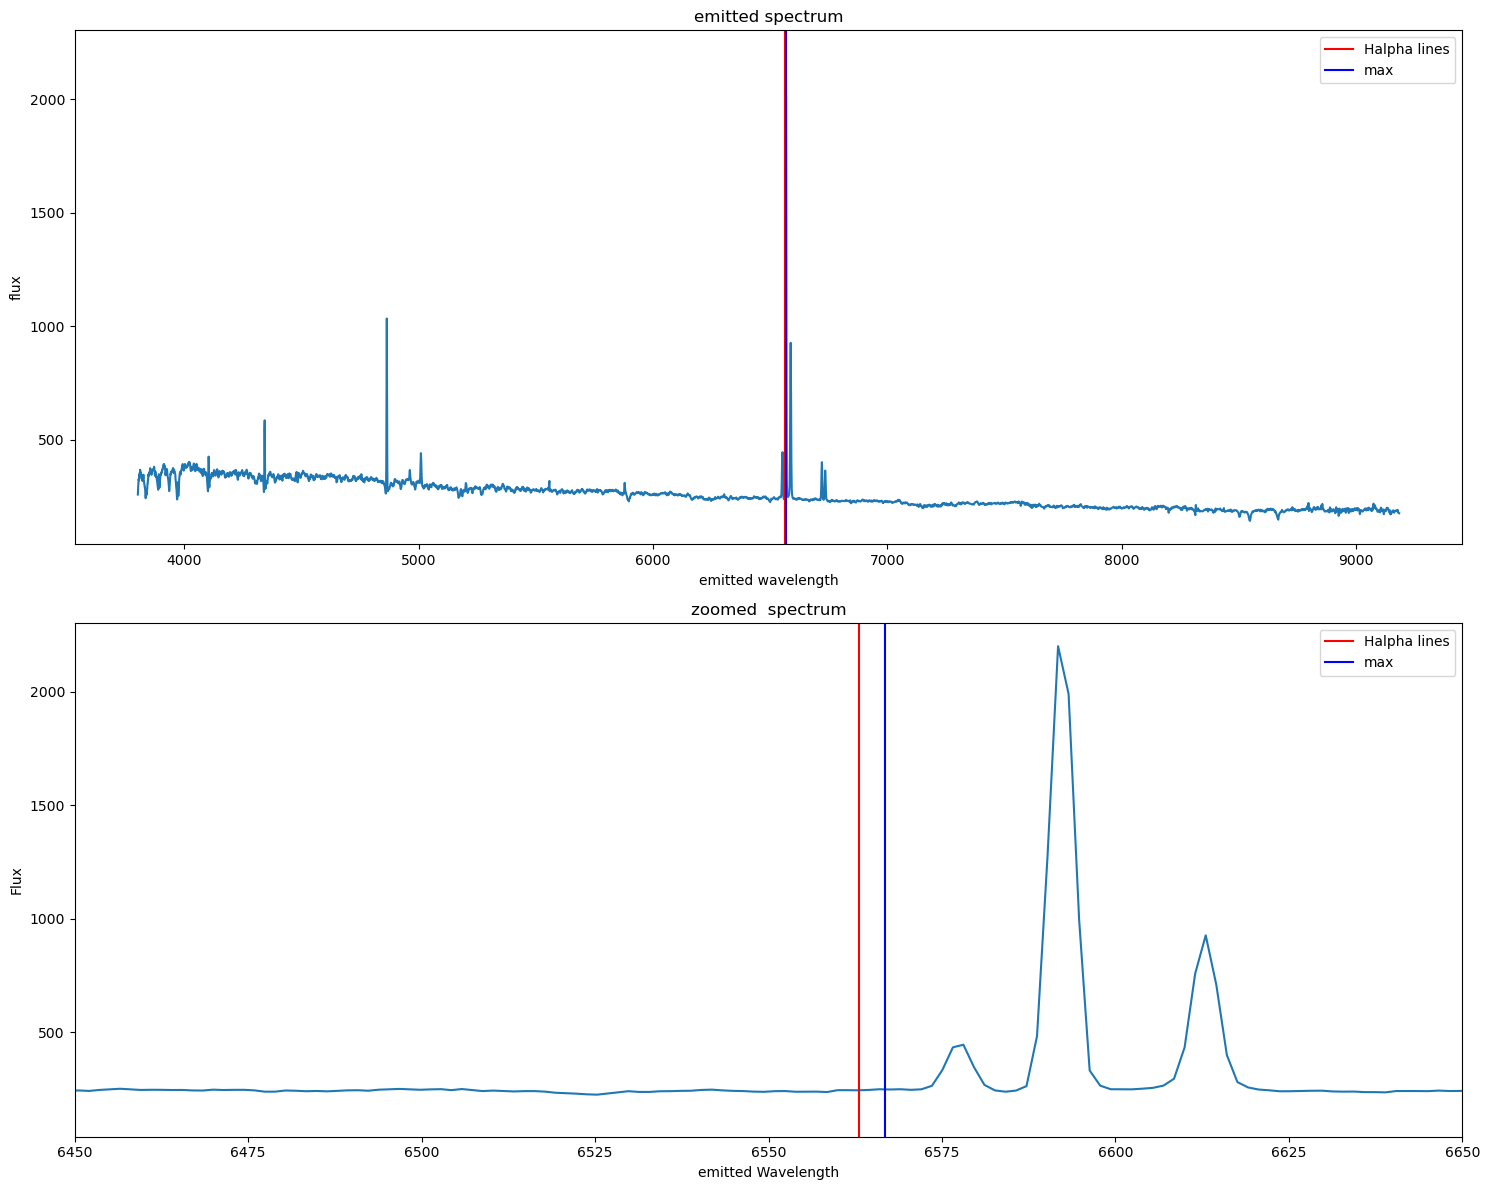

the velocity is 172902.828125


In [31]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

ra = 40.6696 #given constants and coordinated
dec = -0.0133
z = 0.0038
alpha = 6563.0 
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True) #the object

spec = SDSS.get_spectra(matches=xid) #get the spectrum

hdulist = spec[0]

data = hdulist[1].data #get the data

flux = data['flux'] #extract the flux an log wavelength
loglam = data['loglam']

obs = 10**loglam #make it the normal wavelength
emit = obs/(1+z) #calculate the obeserved wavelength
peakemit = emit[max_idx] # Wavelength of peak emitted


fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=False) #plot two frames

ax[0].plot(emit, flux) #plot the first frame (broad)
ax[0].set_title('emitted spectrum')
ax[0].set_xlabel("emitted wavelength")
ax[0].set_ylabel("flux")
ax[0].axvline(x=alpha, color='red', label='Halpha lines')
ax[0].axvline(x=peakemit, color='blue', label='max')
ax[0].legend()

ax[1].plot(obs, flux) #plot the seconde frame (zoomed)
ax[1].set_title('zoomed  spectrum')
ax[1].set_xlabel("emitted Wavelength")
ax[1].set_ylabel("Flux")
ax[1].set_xlim(6450, 6650)
ax[1].axvline(x=alpha, color='red', label='Halpha lines')
ax[1].axvline(x=peakemit, color='blue', label='max')
ax[1].legend()

plt.tight_layout()
plt.show()

velocity = ((peakemit - alpha)*c)/alpha #calculate the velocity
print(f'the velocity is {velocity}')


In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

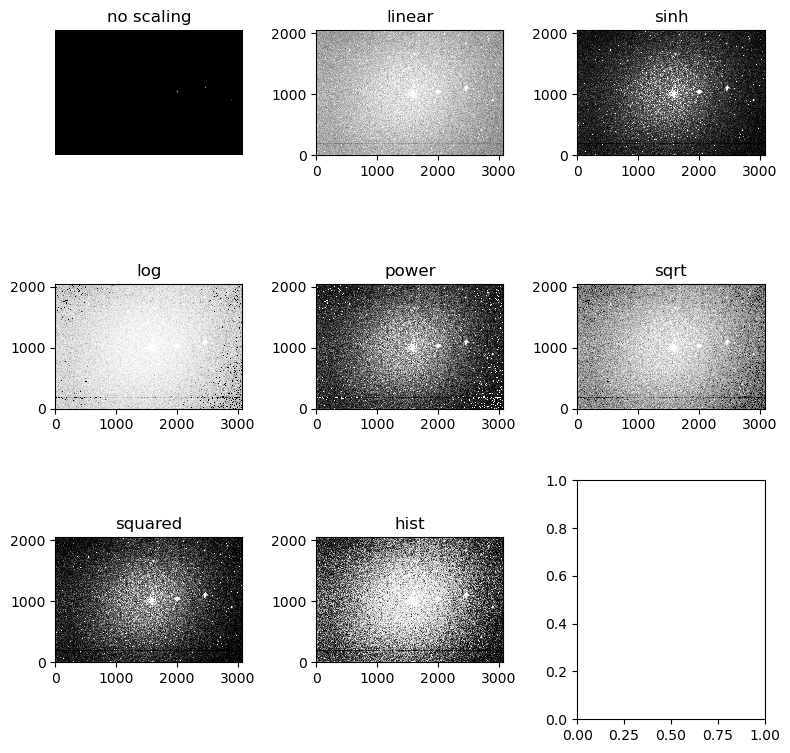

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval


def imdisplay(data,#copy-paste the group)
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

hdulist = fits.open("./Downloads/20210422_Li_.00000066.FIT") #open the file
data = hdulist[0].data #get the data

fig, ax = plt.subplots(3, 3, figsize=(8, 8)) #make the subplots
ax = ax.flatten() 

scales = ['linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']

ax[0].imshow(data, origin='lower', cmap='gray')
ax[0].set_title('no scaling')
ax[0].axis('off')

for i, scale in enumerate(scales, start=1):#use all the scales and plot them
    imdisplay(data, ax=ax[i], scale=scale)  
    ax[i].set_title(scale)



plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

180504_Li_00000059.fits
180504_Li_00000081.fits
180504_Li_00000068.fits
180504_Li_00000070.fits
180504_Li_00000085.fits


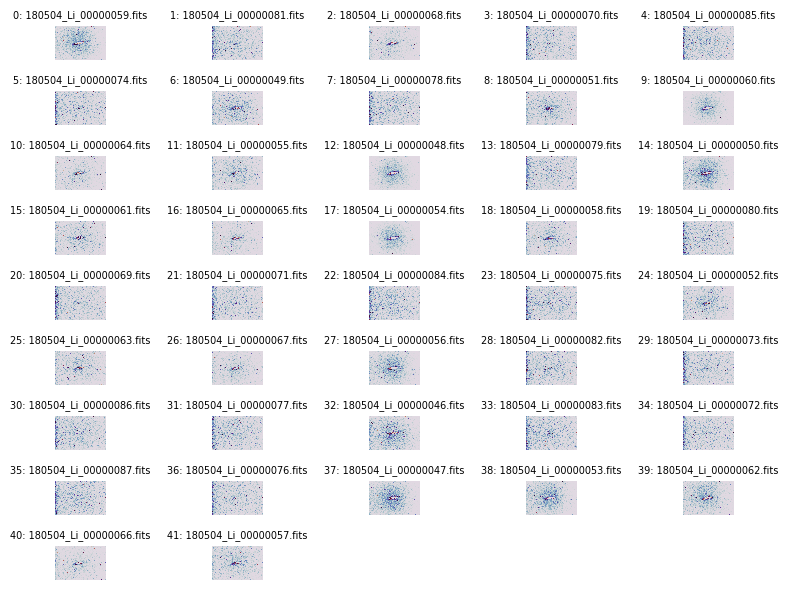

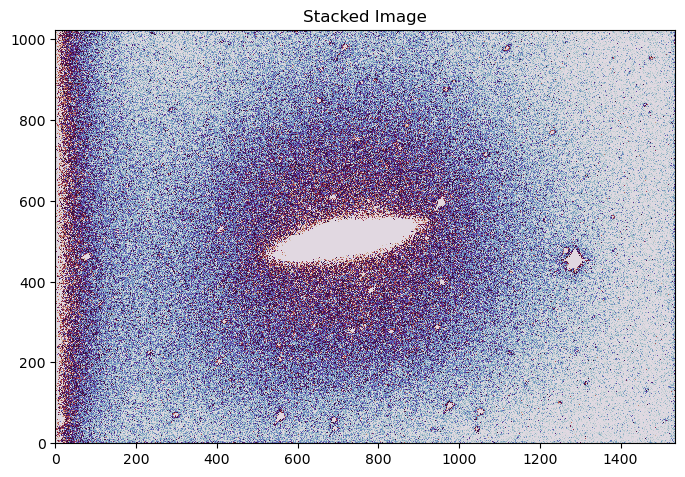

In [56]:
from pathlib import Path
#find files
datadir = "/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/"  # Replace by your own data folder (not in home!)
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

#STEP 1
path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

# Print first 5 file names
for f in filepaths[:5]:
    print(f.name)

from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

#STEP 2
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

#STEP3
from matplotlib.pyplot import figure, show
from astropy.io import fits
from math import ceil

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    images.append(hdulist[0].data) #dont forget to append
    count += 1
    hdulist.close()
show()

#they all look good, so 

# stack them
datacube = np.stack(images)
stacked_images = np.median(datacube, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

imdisplay(stacked_images, ax=ax, percentlow=5, percenthigh=95,
          scale='squared', cmap='twilight')

ax.set_title("Stacked Image")

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")